# 双指针

## 题目目录

- [283-1 移动零](#lc-283)
- [15-2 三数之和](#lc-15)
- [167-5 两数之和 II - 输入有序数组](#lc-167)
- [42-3 接雨水](#lc-42)


<a id="lc-283"></a>

## 283-1 移动零


### 解法笔记 1


### 移动0

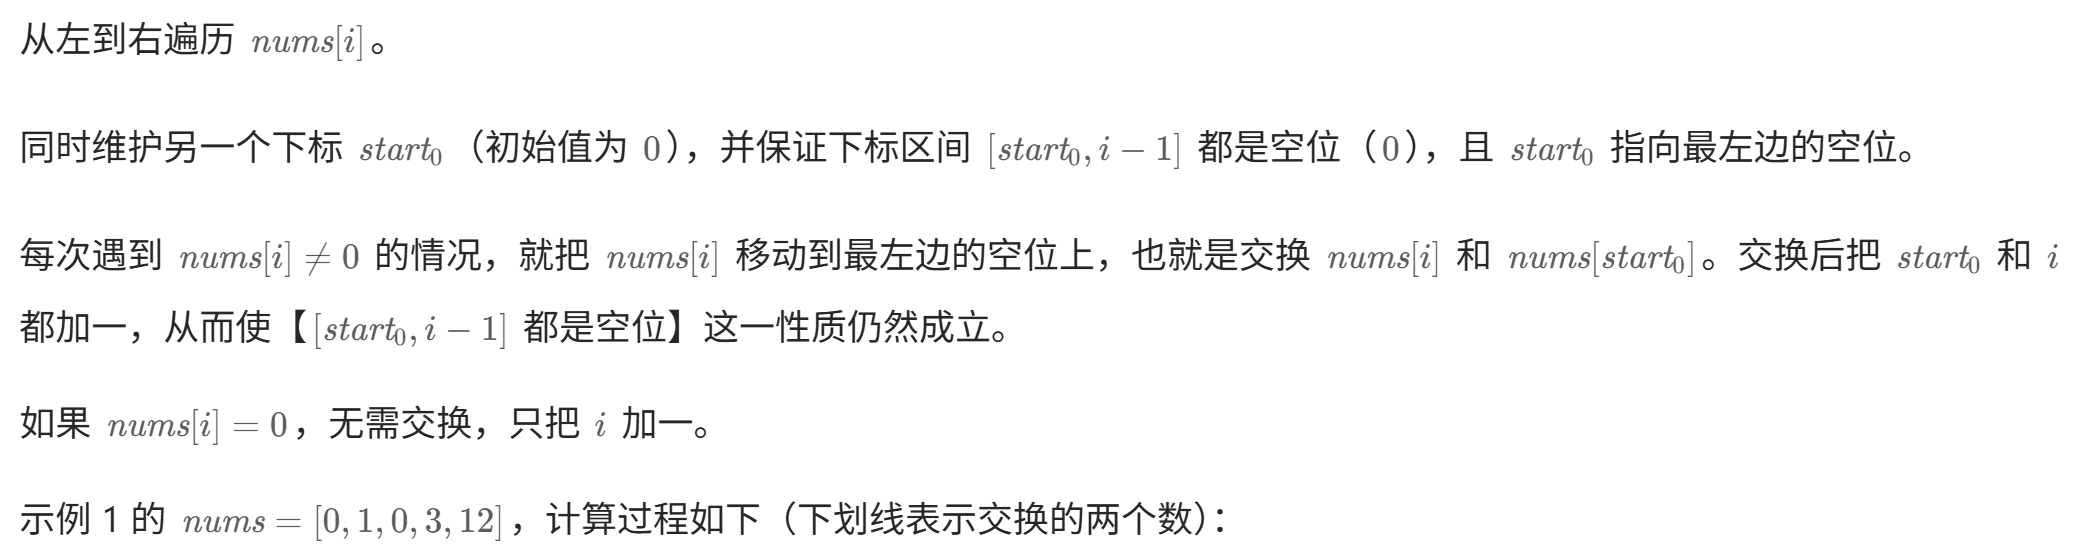


In [ ]:
class Solution:
    def moveZeroes(self, nums: List[int]) -> None:
        """
        循环不变量：在循环过程中，nums 的数据分布始终如下图
        [ 非零元素 | 零元素 | 尚未遍历 ]
                    ^       ^
                    start0  i
        """
        start0 = 0
        for i in range(len(nums)):
            if nums[i]:#如果遇到了非0元素,需要将其与第一个0元素交换位置,然后修改[left,right-1]的边界,但是如果直接遇到一个0元素的话,那么直接加入到[left,right-1]的边界中,不需要交换位置
                nums[i], nums[start0] = nums[start0], nums[i]
                start0 += 1

### 解法笔记 2


### 移动0问题


In [ ]:
class Solution(object):
    def moveZeroes(self, nums):
        """
        :type nums: List[int]
        :rtype: None Do not return anything, modify nums in-place instead.
        """
        length1 = len(nums)
        for i in range(length1):
            num =nums.pop(0)
            if num:
                nums.append(num)
        length2 = len(nums)
        nums.extend([0] * (length1 - length2))
        return nums

列表的相加可以使用：

        1.nums+=[0]*length
        2.nums.extend([0]*length)


<a id="lc-15"></a>

## 15-2 三数之和


### 三数之和（相向双指针）


In [ ]:
class Solution(object):
    def threeSum(self, nums):
        """
        :type nums: List[int]
        :rtype: List[List[int]]
        """
        result = []
        nums.sort()#数据必须是有序的，这样的话后续针对sum与0比较产生的不同操作才有意义
        for i in range(len(nums)-2):#最起码有三个数字才进行循环判断
            if nums[i] >0:
                break
            if nums[i]==nums[i-1] and i>0:#满足这个条件的情况下，num[i-1]已被使用，所以nums[i]不再使用
                continue
            if nums[i] + nums[i+1] + nums[i+2] > 0:#最小的三个数都大于0了，后续的数更大，所以直接break
                break
            if nums[i] + nums[len(nums)-1] + nums[len(nums)-2] < 0:#最大的三个数都小于0了，后续的数更小，所以直接continue
                continue
            else:
                left = i+1
                right = len(nums) - 1
                while(left < right):
                    sum = nums[i] + nums[left] +nums[right]#sum要写在循环里面
                    if sum < 0:
                        left += 1
                    elif sum>0:
                        right -= 1
                    else:
                        result.append([nums[i],nums[left],nums[right]])#已经对可能会重复的数进行了处理，所以直接添加就行
                        while left < right and nums[left]==nums[left+1]:
                            left +=1
                        while left < right and nums[right]==nums[right-1]:
                            right -= 1
                        left += 1
                        right -= 1
        return result

<a id="lc-167"></a>

## 167-5 两数之和 II - 输入有序数组


题解待补充。


<a id="lc-42"></a>

## 42-3 接雨水


### 解法笔记 1


### 接雨水问题（相向双指针）

对于此问题，可以把每个位置当成一个木桶（或木桶的一部分），这个位置能取水的最大值取决于木桶中最短的那块板子。解法一先求每个位置的前缀与后缀的最大值（表明了当前格子实际上位于一个多大的木桶当中），再求前缀与后缀的最小值即是当前单位格子所能存水的最大值，再减去当前的高度即可。


### 解法一：采用前后缀

解法一先求每个位置的前缀与后缀的最大值（表明了当前格子实际上位于一个多大的木桶当中），再求前缀与后缀的最小值即是当前单位格子所能存水的最大值，再减去当前的高度即可。

    时间复杂度为O(n)
    空间复杂度为O(n)


In [ ]:
class Solution(object):
    def trap(self, height):
        length = len(height)
        pre = [0]*length
        post = [0]*length
        pre[0] = height[0]
        post[-1] = height[-1]

        for i in range(1,length):
            pre[i] = max(pre[i-1],height[i])

        for j in range(length-2,-1,-1):
            post[j] = max(post[j+1],height[j])

        res = []
        for x in range(length):
            res.append(min(pre[x],post[x])-height[x])

        return sum(res)

### 解法二：

解法二采用相向双指针的方法，在指针移动的过程中记录前缀与后缀的最大值

短板效应,

    时间复杂度为O(n)
    空间复杂度为O(1)


In [ ]:
class Solution(object):
    def trap(self, height):
        """
        :type height: List[int]
        :rtype: int
        """
        left = 0
        right = len(height) - 1
        pre_max = height[0]
        suf_max = height[-1]
        res = 0
        while left < right:#这个算法写<=或者<都可以,因为对于最高点来说不可能积水.
            pre_max = max(height[left],pre_max)
            suf_max = max(height[right],suf_max)
            if pre_max < suf_max:
                res += pre_max - height[left]
                left += 1
            else:
                res += suf_max - height[right]
                right -=1
        return res

### 解法笔记 2


### 接雨水问题

找下一个最大元素，再找的过程中填坑


In [ ]:
class Solution:
    def trap(self, height) -> int:
        n = len(height)
        stack = []
        num = 0
        for i in range(n):#单调递减（从栈尾到栈顶）
            while stack and height[i] >= height[stack[-1]]:#相同元素只压一次
                bottom = height[stack.pop()]
                if not stack:#这种情况一般是两根柱子连在一起或者两片水连起来了
                    break
                #如果不为空那么一定存在比弹出元素更大的值，因此构成了一个坑，我们的目的就是去填坑
                h = min(height[i],height[stack[-1]]) - bottom
                num += h * (i - stack[-1] -1)
            stack.append(i)
        return num